In [3]:
import xarray as xr
import numpy as np
import os

test_file = '/home/nili/ninna_msc_output/2020/01/01/S1A_EW_GRDM_1SDH_20200101T024913_20200101T025017_030601_038174_4E78_prediction.nc'

ds = xr.open_dataset(test_file)
# print(ds)
print('\nGlobal attributes:')
for k, v in ds.attrs.items():
    if 'gcp' not in k:  # skip long gcp lists
        print(f'  {k}: {v}')

print('\nSIC_pred stats:')
sic = ds['SIC_pred'].values
valid = sic[(sic < 254) & ~np.isnan(sic)]
print(f'  shape      : {sic.shape}')
print(f'  valid pixels: {len(valid)}')
print(f'  min / max  : {valid.min():.1f} / {valid.max():.1f} %')
print(f'  mean       : {valid.mean():.1f} %')
print(f'  land (254) : {(sic == 254).sum()}')
print(f'  missing(255): {(sic == 255).sum()}')

print(f'\nGCP points: {len(ds.attrs["gcp_lats"])}')
print(f'Lat range  : {min(ds.attrs["gcp_lats"]):.2f} – {max(ds.attrs["gcp_lats"]):.2f} °N')
print(f'Lon range  : {min(ds.attrs["gcp_lons"]):.2f} – {max(ds.attrs["gcp_lons"]):.2f} °E')

# ds.close()


Global attributes:
  model: fusionnetaspp postfix=5
  model_epoch: 214
  val_rmse: 5.864811811908599
  val_mae: 2.370959989486202
  timestamp: 20200101T024913
  source_amsr2: AMSR2_S1A_EW_GRDM_1SDH_20200101T024913_20200101T025017_030601_038174_4E78.nc
  source_sar: S1A_EW_GRDM_1SDH_20200101T024913_20200101T025017_030601_038174_4E78.zip
  crs: EPSG:3411
  grid_spacing: ~2km  (resampled onto Sentinel-1 GCP grid)

SIC_pred stats:
  shape      : (214, 208)
  valid pixels: 41352
  min / max  : 22.2 / 100.0 %
  mean       : 98.7 %
  land (254) : 646
  missing(255): 2514

GCP points: 483
Lat range  : 76.87 – 81.96 °N
Lon range  : 58.89 – 86.21 °E


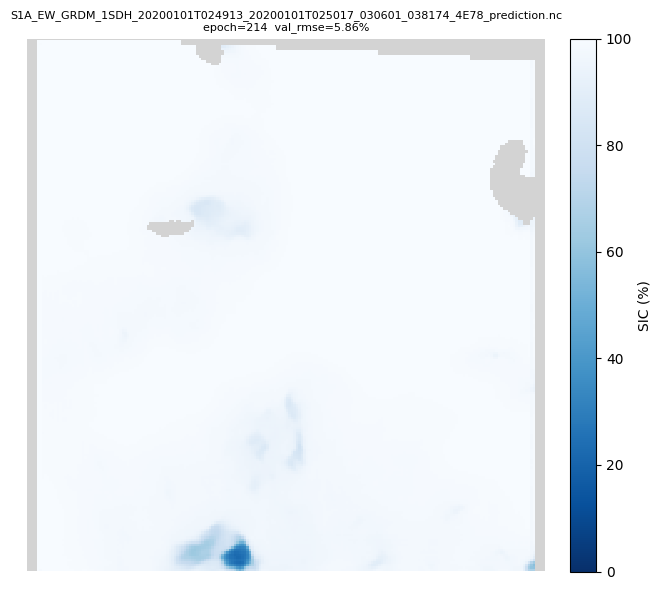

In [2]:
import matplotlib.pyplot as plt
import numpy as np

sic = ds['SIC_pred'].values.astype(float)

# Mask sentinel values for plotting
sic_plot = sic.copy()
sic_plot[sic >= 254] = np.nan

cmap = plt.cm.Blues_r.copy()
cmap.set_bad('lightgray')

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
im = ax.imshow(sic_plot, cmap=cmap, vmin=0, vmax=100, interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='SIC (%)')
ax.set_title(f'{os.path.basename(test_file)}\n'
             f'epoch={ds.attrs["model_epoch"]}  '
             f'val_rmse={ds.attrs["val_rmse"]:.2f}%', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.show()

['', 'home', 'nili', 'ninna_msc_output', '2020', '01', '01', 'S1A_EW_GRDM_1SDH_20200101T024913_20200101T025017_030601_038174_4E78_prediction.nc']
SIC path: /dmidata/projects/asip-cms/reproc/2020/01/01/S1A_EW_GRDM_1SDH_20200101T024913_20200101T025017_030601_038174_4E78_SIC.tiff


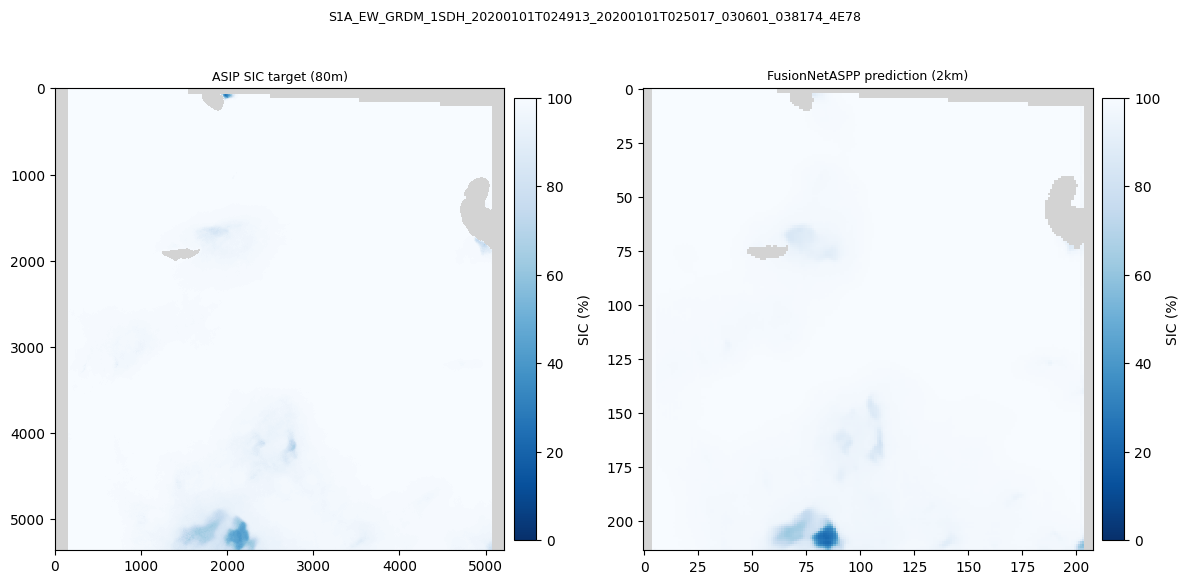

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import rioxarray
SIC_BASE = '/dmidata/projects/asip-cms/reproc'

# Derive SIC path from the prediction file path
parts    = test_file.split('/')
date_idx = parts.index('ninna_msc_output') + 1
y, m, d  = parts[date_idx], parts[date_idx+1], parts[date_idx+2]
scene_id = os.path.basename(test_file).replace('_prediction.nc', '')
sic_path = os.path.join(SIC_BASE, y, m, d, scene_id + '_SIC.tiff')
print(f'SIC path: {sic_path}')

# Load native SIC
with rioxarray.open_rasterio(sic_path) as da:
    sic_native = da.values[0].astype(np.float32)

# Mask invalid
sic_native_plot = sic_native.copy()
sic_native_plot[sic_native >= 254] = np.nan

# Load prediction
sic_pred = ds['SIC_pred'].values.astype(float)
sic_pred_plot = sic_pred.copy()
sic_pred_plot[sic_pred >= 254] = np.nan


cmap_sic  = plt.cm.Blues_r.copy(); cmap_sic.set_bad('lightgray')
cmap_diff = plt.cm.bwr.copy();     cmap_diff.set_bad('lightgray')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

im0 = axes[0].imshow(sic_native_plot, cmap=cmap_sic, vmin=0, vmax=100, interpolation='nearest')
axes[0].set_title('ASIP SIC target (80m)', fontsize=9)
# axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02, label='SIC (%)')

im1 = axes[1].imshow(sic_pred_plot, cmap=cmap_sic, vmin=0, vmax=100, interpolation='nearest')
axes[1].set_title(f'FusionNetASPP prediction (2km)', fontsize=9)
# axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02, label='SIC (%)')


fig.suptitle(
    f'{scene_id}\n',
    fontsize=9,
)
plt.tight_layout()
plt.show()

With other landmask than from ASIP

In [7]:
# Run this on one of the failing files to see the GCP extent
from pyproj import Transformer
import zipfile, xml.etree.ElementTree as ET, numpy as np
def read_gcp_from_zip(zip_path):
    """Reads GCPs from a Sentinel-1 zip file annotation XML."""
    with zipfile.ZipFile(zip_path, 'r') as z:
        ann_file = [f for f in z.namelist()
                    if f.endswith('.xml')
                    and 'calibration' not in f
                    and 'rfi' not in f        # ← exclude RFI annotation
                    and 'hh' in f][0]
        with z.open(ann_file) as f:
            tree = ET.parse(f)

    gcps   = tree.getroot().findall('.//geolocationGridPoint')
    if len(gcps) == 0:
        raise ValueError(f'No GCP points found in {zip_path}')
    lines  = np.array([int(g.find('line').text)        for g in gcps])
    pixels = np.array([int(g.find('pixel').text)       for g in gcps])
    lats   = np.array([float(g.find('latitude').text)  for g in gcps])
    lons   = np.array([float(g.find('longitude').text) for g in gcps])
    return lines, pixels, lats, lons

sar_path = '/dmidata/projects/asip-cms/sentinel1/2022/01/01/S1A_EW_GRDM_1SDH_20220101T020815_20220101T020919_041261_04E75F_5F42.zip'

with zipfile.ZipFile(sar_path, 'r') as z:
    xml_files = [f for f in z.namelist() if f.endswith('.xml')]
    print('All XML files:')
    for f in xml_files:
        print(f'  {f}')
    
    ann_files = [f for f in z.namelist() if f.endswith('.xml') and 'calibration' not in f]
    print(f'\nAnnotation candidates (no calibration): {ann_files}')
    
    hh_files = [f for f in ann_files if 'hh' in f]
    print(f'\nHH annotation files: {hh_files}')

gcps = tree.getroot().findall('.//geolocationGridPoint')
print(f'Number of GCPs: {len(gcps)}')
lines, pixels, lats, lons = read_gcp_from_zip(sar_path)

transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3411', always_xy=True)
x, y = transformer.transform(lons, lats)
print(f'x range: {x.min():.0f} – {x.max():.0f} m')
print(f'y range: {y.min():.0f} – {y.max():.0f} m')
print(f'Current REF_EXT: ±6,000,000 m')

All XML files:
  S1A_EW_GRDM_1SDH_20220101T020815_20220101T020919_041261_04E75F_5F42.SAFE/annotation/calibration/calibration-s1a-ew-grd-hh-20220101t020815-20220101t020919-041261-04e75f-001.xml
  S1A_EW_GRDM_1SDH_20220101T020815_20220101T020919_041261_04E75F_5F42.SAFE/annotation/calibration/calibration-s1a-ew-grd-hv-20220101t020815-20220101t020919-041261-04e75f-002.xml
  S1A_EW_GRDM_1SDH_20220101T020815_20220101T020919_041261_04E75F_5F42.SAFE/annotation/calibration/noise-s1a-ew-grd-hh-20220101t020815-20220101t020919-041261-04e75f-001.xml
  S1A_EW_GRDM_1SDH_20220101T020815_20220101T020919_041261_04E75F_5F42.SAFE/annotation/calibration/noise-s1a-ew-grd-hv-20220101t020815-20220101t020919-041261-04e75f-002.xml
  S1A_EW_GRDM_1SDH_20220101T020815_20220101T020919_041261_04E75F_5F42.SAFE/annotation/rfi/rfi-s1a-ew-grd-hh-20220101t020815-20220101t020919-041261-04e75f-001.xml
  S1A_EW_GRDM_1SDH_20220101T020815_20220101T020919_041261_04E75F_5F42.SAFE/annotation/rfi/rfi-s1a-ew-grd-hv-20220101t020815

Loading: /dmidata/projects/asip-cms/ninna_msc/output/2020/01/05/S1A_EW_GRDM_1SDH_20200105T021822_20200105T021922_030659_038384_1A11_prediction.nc

Shape       : (199, 208)
Valid pixels: 28476
SIC range   : 54.4 – 100.0 %
SIC mean    : 97.8 %
Land (254)  : 11979
GCP points  : 441
Lat range   : 70.22 – 74.73 °N
Lon range   : 61.56 – 76.92 °E
SIC path: /dmidata/projects/asip-cms/reproc/2020/01/05/S1A_EW_GRDM_1SDH_20200105T021822_20200105T021922_030659_038384_1A11_SIC.tiff


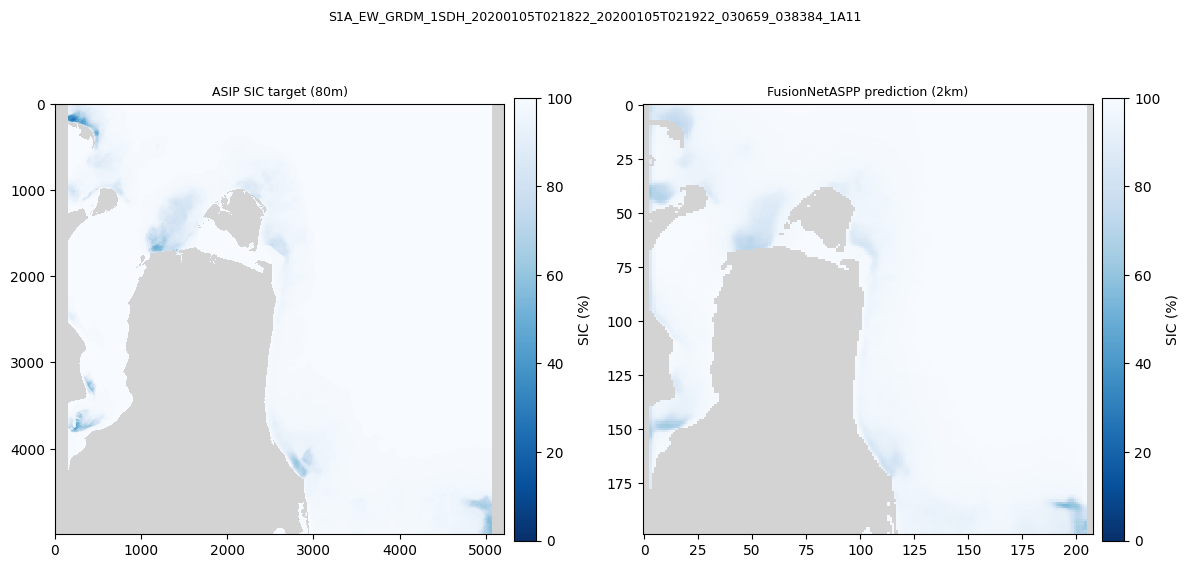

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Find first prediction file
files = sorted(glob.glob('/dmidata/projects/asip-cms/ninna_msc/output/2020/**/**/*_prediction.nc'))
test_file = files[500]
print(f'Loading: {test_file}')

ds  = xr.open_dataset(test_file)
sic = ds['SIC_pred'].values.astype(float)

# Stats
valid = sic[sic < 254]
print(f'\nShape       : {sic.shape}')
print(f'Valid pixels: {len(valid)}')
print(f'SIC range   : {valid.min():.1f} – {valid.max():.1f} %')
print(f'SIC mean    : {valid.mean():.1f} %')
print(f'Land (254)  : {(sic == 254).sum()}')
print(f'GCP points  : {len(ds.attrs["gcp_lats"])}')
print(f'Lat range   : {min(ds.attrs["gcp_lats"]):.2f} – {max(ds.attrs["gcp_lats"]):.2f} °N')
print(f'Lon range   : {min(ds.attrs["gcp_lons"]):.2f} – {max(ds.attrs["gcp_lons"]):.2f} °E')

# # Plot
# sic_plot = sic.copy()
# sic_plot[sic >= 254] = np.nan

# cmap = plt.cm.Blues_r.copy()
# cmap.set_bad('lightgray')   # ocean/invalid
# cmap.set_over('#8B4513')    # land (254) shown as brown

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # SIC prediction
# im0 = axes[0].imshow(sic_plot, cmap=cmap, vmin=0, vmax=100, interpolation='nearest')
# axes[0].set_title('SIC prediction', fontsize=10)
# axes[0].axis('off')
# plt.colorbar(im0, ax=axes[0], fraction=0.046, label='SIC (%)')

# # Land mask check — show where 254 values are
# land_plot = (sic == 254).astype(float)
# land_plot[land_plot == 0] = np.nan

# im1 = axes[1].imshow(sic_plot, cmap=cmap, vmin=0, vmax=100,
#                      interpolation='nearest', alpha=0.8)

# axes[1].imshow(land_plot, cmap='Reds', vmin=0, vmax=1,
#                interpolation='nearest', alpha=0.6)
# axes[1].set_title('Land mask overlay (red = 254)', fontsize=10)
# axes[1].axis('off')
# plt.colorbar(im1, ax=axes[1], fraction=0.046, label='SIC (%)')

# plt.suptitle(f'{os.path.basename(test_file)}\n'
#              f'epoch={ds.attrs["model_epoch"]}  val_rmse={ds.attrs["val_rmse"]:.2f}%',
#              fontsize=9)
# plt.tight_layout()
# plt.show()
# ds.close()

import matplotlib.pyplot as plt
import numpy as np
import rioxarray
SIC_BASE = '/dmidata/projects/asip-cms/reproc'

# Derive SIC path from the prediction file path
parts    = test_file.split('/')
date_idx = parts.index('output') + 1
y, m, d  = parts[date_idx], parts[date_idx+1], parts[date_idx+2]
scene_id = os.path.basename(test_file).replace('_prediction.nc', '')
sic_path = os.path.join(SIC_BASE, y, m, d, scene_id + '_SIC.tiff')
print(f'SIC path: {sic_path}')

# Load native SIC
with rioxarray.open_rasterio(sic_path) as da:
    sic_native = da.values[0].astype(np.float32)

# Mask invalid
sic_native_plot = sic_native.copy()
sic_native_plot[sic_native >= 254] = np.nan

# Load prediction
sic_pred = ds['SIC_pred'].values.astype(float)
sic_pred_plot = sic_pred.copy()
sic_pred_plot[sic >= 254] = np.nan


cmap_sic  = plt.cm.Blues_r.copy(); cmap_sic.set_bad('lightgray')
cmap_diff = plt.cm.bwr.copy();     cmap_diff.set_bad('lightgray')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

im0 = axes[0].imshow(sic_native_plot, cmap=cmap_sic, vmin=0, vmax=100, interpolation='nearest')
axes[0].set_title('ASIP SIC target (80m)', fontsize=9)
# axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02, label='SIC (%)')

im1 = axes[1].imshow(sic_pred_plot, cmap=cmap_sic, vmin=0, vmax=100, interpolation='nearest')
axes[1].set_title(f'FusionNetASPP prediction (2km)', fontsize=9)
# axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02, label='SIC (%)')


fig.suptitle(
    f'{scene_id}\n',
    fontsize=9,
)
plt.tight_layout()
plt.show()

Measurement files:
  S1A_EW_GRDM_1SDH_20200101T025017_20200101T025117_030601_038174_2410.SAFE/measurement/s1a-ew-grd-hh-20200101t025017-20200101t025117-030601-038174-001.tiff
  S1A_EW_GRDM_1SDH_20200101T025017_20200101T025117_030601_038174_2410.SAFE/measurement/s1a-ew-grd-hv-20200101t025017-20200101t025117-030601-038174-002.tiff


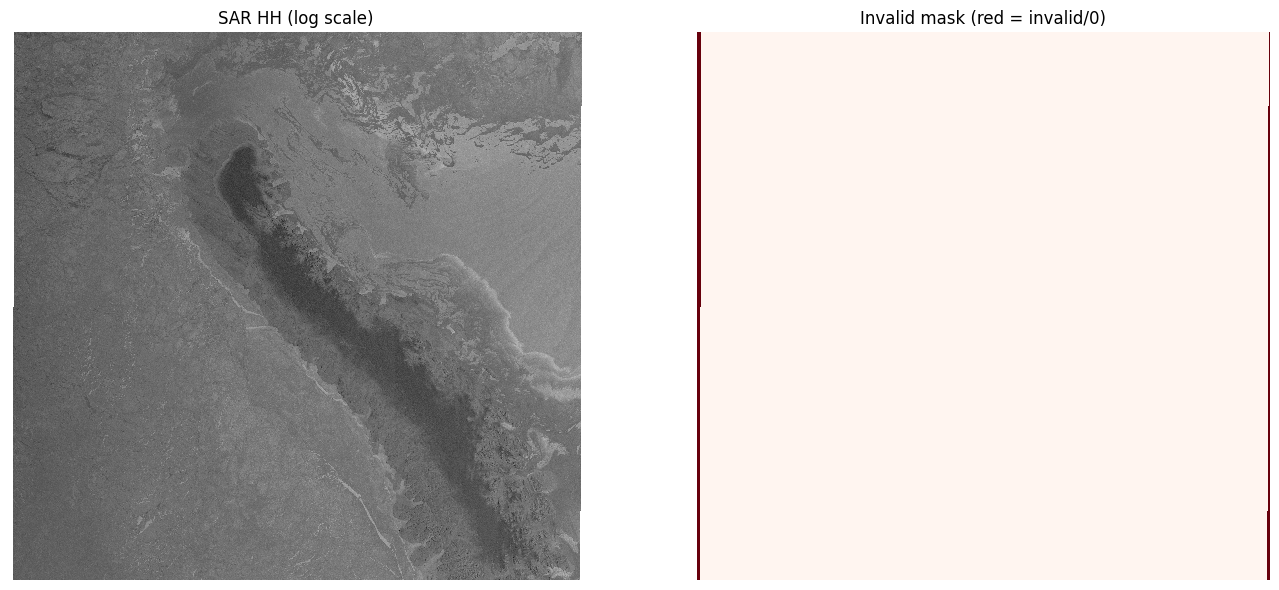

In [46]:
import zipfile
import numpy as np
import rioxarray
import io

sar_path = '/dmidata/projects/asip-cms/sentinel1/2020/01/01/S1A_EW_GRDM_1SDH_20200101T025017_20200101T025117_030601_038174_2410.zip'

with zipfile.ZipFile(sar_path, 'r') as z:
    # Find measurement tiffs
    tiffs = sorted([f for f in z.namelist() if 'measurement' in f and f.endswith('.tiff')])
    print('Measurement files:')
    for t in tiffs:
        print(f'  {t}')

    # Load HH
    with z.open(tiffs[0]) as f1:
        hh_bytes = io.BytesIO(f1.read())
    with z.open(tiffs[1]) as f2:
        hv_bytes = io.BytesIO(f2.read())

with rioxarray.open_rasterio(hh_bytes) as da:
    hh = da.values[0].astype(np.float32)
with rioxarray.open_rasterio(hv_bytes) as da:
    hv = da.values[0].astype(np.float32)

# Invalid pixels are 0 in the raw DN values
invalid_sar = np.zeros_like(hh)
invalid_sar[hv == 0] = 1
invalid_sar[hh == 0] = 1
# print(f'\nSAR HH shape    : {hh.shape}')
# print(f'Invalid pixels  : {invalid_sar.sum()} / {invalid_sar.size} ({100*invalid_sar.mean():.1f}%)')
# print(f'Valid range     : {hh[~invalid_sar].min():.0f} – {hh[~invalid_sar].max():.0f} DN')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(np.log1p(hh), cmap='Greys', interpolation='nearest')
axes[0].set_title('SAR HH (log scale)')
axes[0].axis('off')
axes[1].imshow(invalid_sar, cmap='Reds', interpolation='nearest')
axes[1].set_title('Invalid mask (red = invalid/0)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

/dmidata/users/nili/miniforge3/envs/master/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)


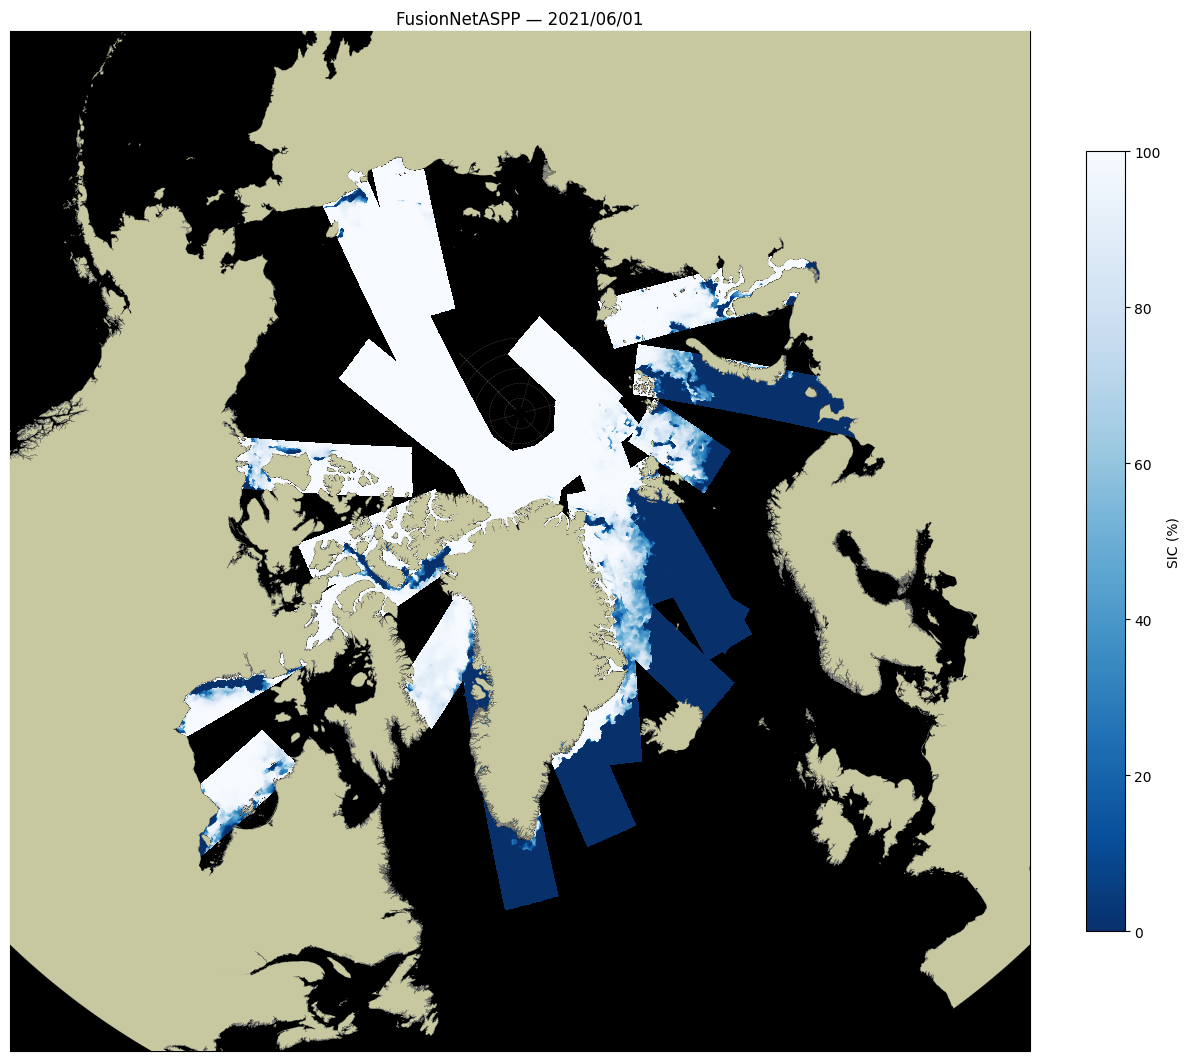

In [ ]:
import os
import glob
import numpy as np
import rioxarray
import xarray as xr
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import RectBivariateSpline
import zipfile
import xml.etree.ElementTree as ET
from pyproj import Transformer
import geopandas as gpd
from NorthPolStere import NorthPolStere

shp = gpd.read_file('/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Code/lib/predict/arctic_shp/op_str_maps_circum_polar_40_EPSG3411.shp')

transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3411', always_xy=True)
# ── Config ────────────────────────────────────────────────────────────────────
DATE      = '2021/06/01'
SIC_BASE  = '/home/nili/ninna_msc_output'
y, m, d   = DATE.split('/')
sic_files = sorted(glob.glob(os.path.join(SIC_BASE, y, m, d, '*.nc')))
# print(xr.open_dataset(sic_files[0]))
cmap = plt.cm.Blues_r.copy()
cmap.set_bad('none')

proj = NorthPolStere()
fig, ax = plt.subplots(1, 1, figsize=(12, 12), subplot_kw={'projection': proj})
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
ax.set_facecolor('black')

for sic_path in sic_files:
    try:
        ds     = xr.open_dataset(sic_path)
        sic    = ds['SIC_pred'].values.astype(np.float32)
        lats   = np.array(ds.attrs['gcp_lats'])
        lons   = np.array(ds.attrs['gcp_lons'])
        lines  = np.array(ds.attrs['gcp_lines'])
        pixels = np.array(ds.attrs['gcp_pixels'])
        ds.close()

        grid_h, grid_w = sic.shape

        n_lines  = len(np.unique(lines))
        n_pixels = len(np.unique(pixels))

        # Project GCP lon/lat → x/y in EPSG:3411
        gcp_x, gcp_y = transformer.transform(
            lons.reshape(n_lines, n_pixels),
            lats.reshape(n_lines, n_pixels)
        )

        # Interpolate projected GCPs to full grid
        x_interp = RectBivariateSpline(
            lines.reshape(n_lines, n_pixels)[:, 0],
            pixels.reshape(n_lines, n_pixels)[0, :],
            gcp_x)
        y_interp = RectBivariateSpline(
            lines.reshape(n_lines, n_pixels)[:, 0],
            pixels.reshape(n_lines, n_pixels)[0, :],
            gcp_y)

        row_coords = np.linspace(0, lines.max(), grid_h)
        col_coords = np.linspace(0, pixels.max(), grid_w)
        x_scene    = x_interp(row_coords, col_coords)
        y_scene    = y_interp(row_coords, col_coords)

        sic_valid = sic.copy()
        sic_valid[sic >= 254] = np.nan

        ax.pcolormesh(x_scene, y_scene, sic_valid,
                      cmap=cmap, vmin=0, vmax=100,
                      shading='auto', zorder=4)

    except Exception as e:
        print(f'Error processing {os.path.basename(sic_path)}: {e}')

shp.plot(ax=ax, facecolor='#c8c8a0', edgecolor='gray',
         linewidth=0.1, zorder=5)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                  alpha=0.5, linestyle='--')
gl.top_labels   = False
gl.right_labels = False

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=100))
sm.set_array([])
plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.05, label='SIC (%)', shrink=0.7)
ax.set_title(f'SPICE — {DATE}', fontsize=12)
plt.tight_layout()
plt.show()

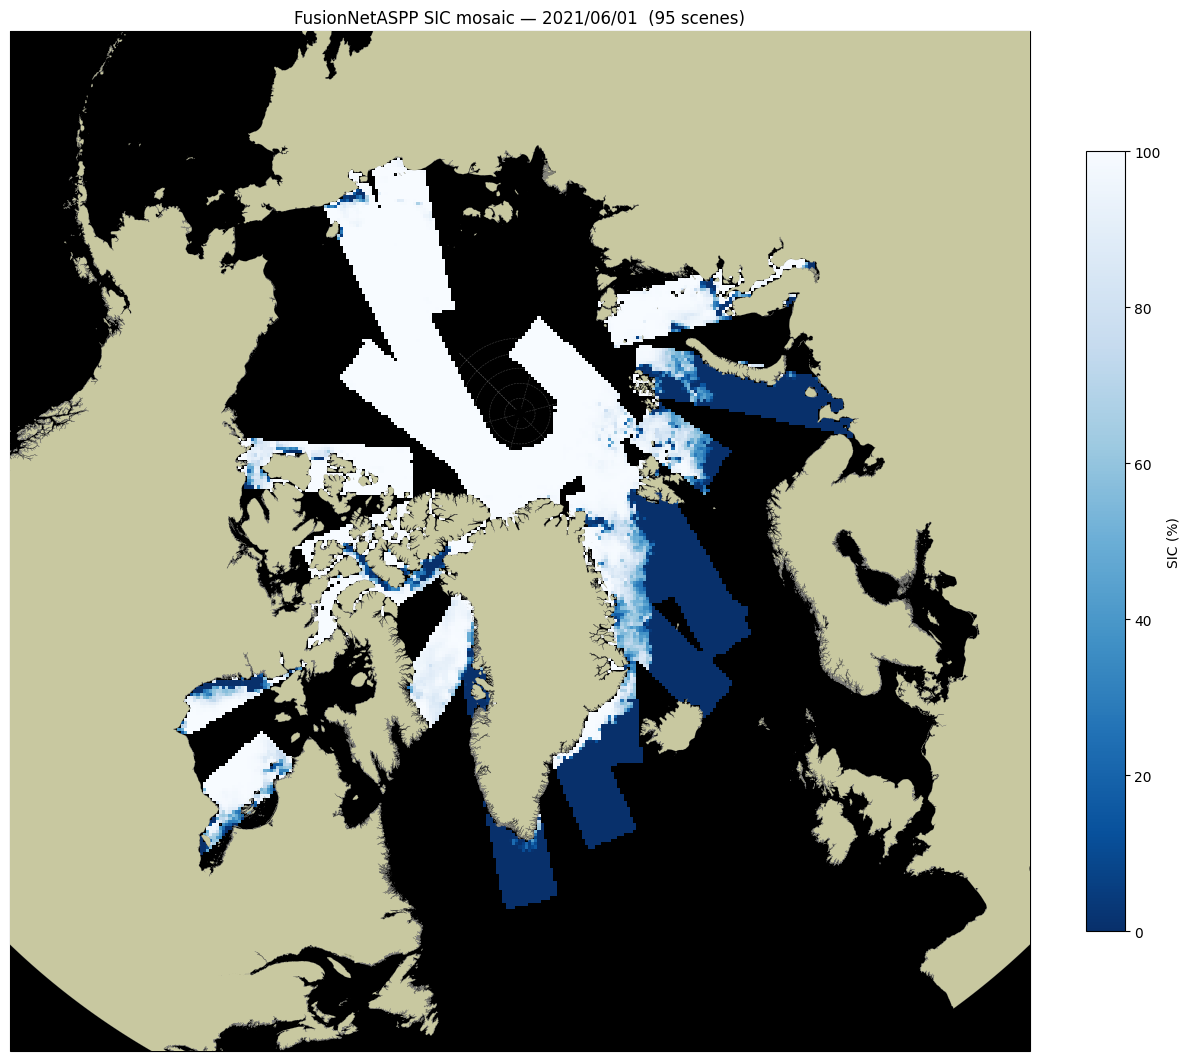

In [7]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from pyproj import Transformer
import geopandas as gpd
from NorthPolStere import NorthPolStere

shp = gpd.read_file('/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Code/lib/predict/arctic_shp/op_str_maps_circum_polar_40_EPSG3411.shp')

transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3411', always_xy=True)


# ── Config ────────────────────────────────────────────────────────────────────
DATE       = '2021/06/15'
for day in range(1, 2):  # Example: iterate through days 1 to 31
    day_str = f'{day:02d}'  # Format day as two digits
    DATE = f'2021/06/{day_str}'
    SIC_BASE   = '/dmidata/projects/asip-cms/ninna_msc/output_mosaic'
    y, m, d    = DATE.split('/')
    sic_files  = sorted(glob.glob(os.path.join(SIC_BASE, y, m, f'SIC_mosaic_{y}{m}{d}.nc')))

    cmap = plt.cm.Blues_r.copy()
    cmap.set_bad('none')

    proj = NorthPolStere()
    fig, ax = plt.subplots(1, 1, figsize=(12, 12), subplot_kw={'projection': proj})
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.set_facecolor('black')

    for sic_path in sic_files:
        try:
            ds      = xr.open_dataset(sic_path)
            sic     = ds['SIC'].values.astype(np.float32)
            lon_out = ds['lon'].values
            lat_out = ds['lat'].values
            n_scenes = ds.attrs.get('n_scenes', '?')
            ds.close()

            x_scene, y_scene = transformer.transform(lon_out, lat_out)

            ax.pcolormesh(x_scene, y_scene, sic,
                        cmap=cmap, vmin=0, vmax=100,
                        shading='auto', zorder=4)

        except Exception as e:
            print(f'Error processing {os.path.basename(sic_path)}: {e}')

    shp.plot(ax=ax, facecolor='#c8c8a0', edgecolor='gray',
            linewidth=0.1, zorder=5)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                    alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=100))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.05, label='SIC (%)', shrink=0.7)
    ax.set_title(f'FusionNetASPP SIC mosaic — {DATE}  ({n_scenes} scenes)', fontsize=12)
    plt.tight_layout()
    plt.show()

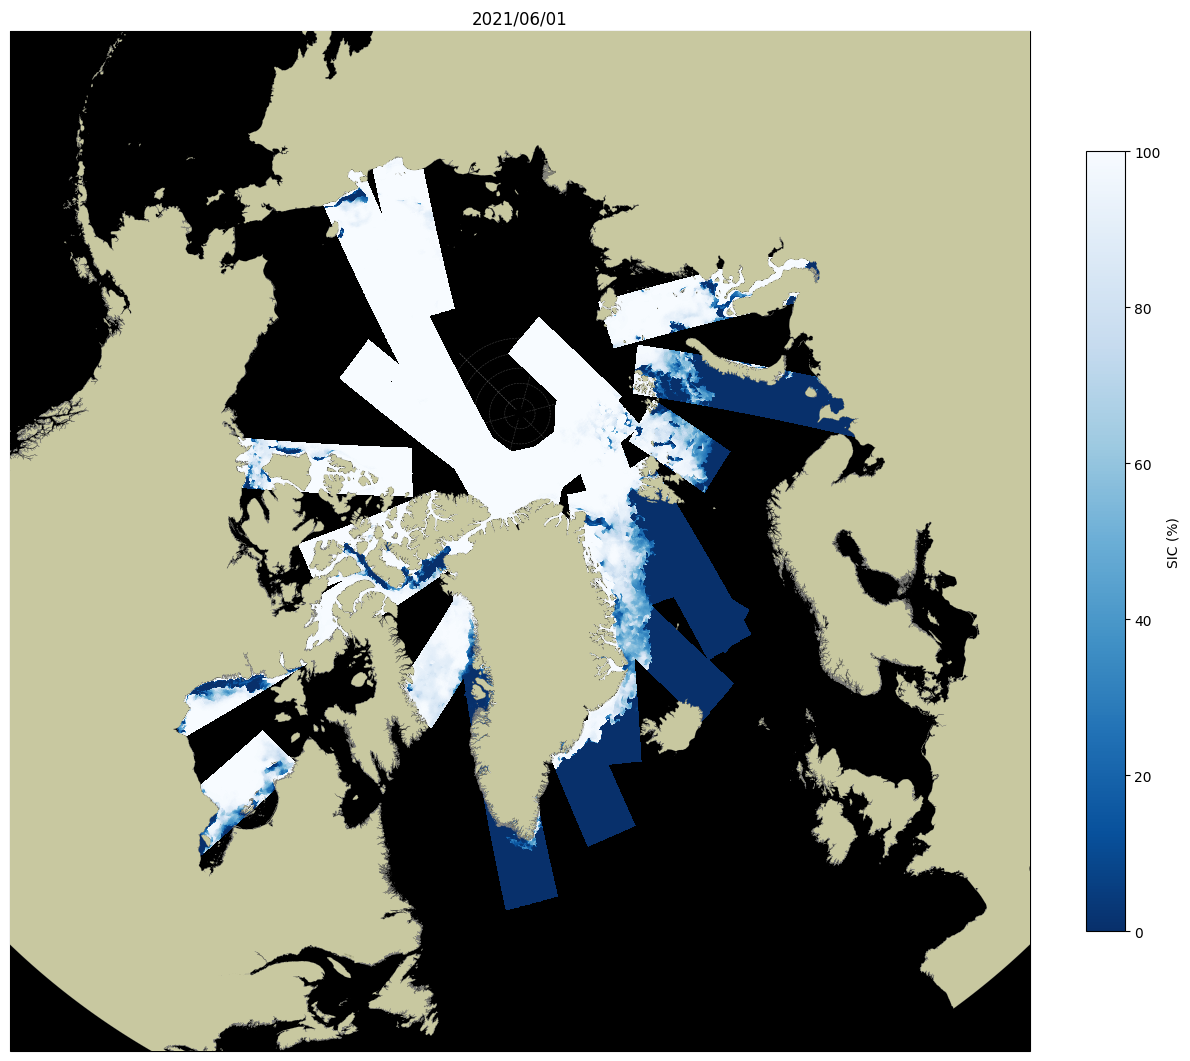

In [11]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import geopandas as gpd
from pyproj import Transformer
from NorthPolStere import NorthPolStere


shp = gpd.read_file('/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/Code/lib/predict/arctic_shp/op_str_maps_circum_polar_40_EPSG3411.shp')
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:3411', always_xy=True)

DATE     = '2021/06/01'
y, m, d  = DATE.split('/')
ymin, ymax = 7500, 20000
xmin, xmax = 1500, 13500

# ── Load directly from the date file ─────────────────────────────────────────
asip_file = f'/dmidata/projects/asip-cms/reproc/mosaics/level3_0500m_v1/dmi_asip_seaice_mosaic_arc_l3_{y}{m}{d}.nc'
ds  = xr.open_dataset(asip_file, engine='h5netcdf')
sic = ds['sic'][0, ymin:ymax, xmin:xmax].values.astype(np.float32)
lat = ds['lat'][ymin:ymax, xmin:xmax].values
lon = ds['lon'][ymin:ymax, xmin:xmax].values
ds.close()

sic[sic > 100] = np.nan
sic[sic < 0]   = np.nan

# Downsample 500m → 25km for plotting speed
step = 50
sic_ds  = sic#[::step, ::step]
lat_ds  = lat#[::step, ::step]
lon_ds  = lon#[::step, ::step]

x_grid, y_grid = transformer.transform(lon_ds, lat_ds)

# ── Plot ──────────────────────────────────────────────────────────────────────
cmap = plt.cm.Blues_r.copy()
cmap.set_bad('none')

proj = NorthPolStere()
fig, ax = plt.subplots(1, 1, figsize=(12, 12), subplot_kw={'projection': proj})
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
ax.set_facecolor('black')

ax.pcolormesh(x_grid, y_grid, sic_ds,
              transform=NorthPolStere(),
              cmap=cmap, vmin=0, vmax=100,
              shading='auto', zorder=4)

shp.plot(ax=ax, facecolor='#c8c8a0', edgecolor='gray',
         linewidth=0.1, zorder=5)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray',
                  alpha=0.5, linestyle='--')
gl.top_labels   = False
gl.right_labels = False

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=100))
sm.set_array([])
plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.05, label='SIC (%)', shrink=0.7)
ax.set_title(f'{DATE}', fontsize=12)
plt.tight_layout()
plt.savefig('/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/figures/presentation/ASIP_day.png', dpi=300, bbox_inches='tight')
plt.show()